# Topic 6. Higher-order functions and modular programming

In this notebook, we will see that higher-order functions (HOFs) are essential modularity devices, and we will introduce the most common higher-order functions that operate over many different data structures.

### References

[__Programming in Scala, 
A comprehensive step-by-step guide__](https://www.artima.com/shop/programming_in_scala_3ed) Third Edition.
by Martin Odersky, Lex Spoon, and Bill Venners. 

- Chapter 6. Functional objects
- Chapter 8. Functions and closures
- Chapter 16. Working with Lists
- Chapter 23. For Expressions Revisited

[__Functional programming in Scala__](https://www.manning.com/books/functional-programming-in-scala), by Paul Chiusano and Runar Bjarnason.

- Chapter 3. Functional data structures

[__Functional programming simplified__](https://alvinalexander.com/downloads/fpsimplified-free-preview.pdf), by Alvin Alexander.

- Chapter 22. Functions Are Variables, Too
- Chapter 23. Using Methods As If They Were Functions
- Chapter 24. How to Write Functions That Take Functions as Input Parameters
- Chapter 25. How to Write a ‘map’ Function
- Chapter 27. Functions Can Have Multiple Parameter Groups
- Chapter 28. Partially-Applied Functions (and Currying)

In [1]:
import $ivy.`org.scalatest::scalatest:3.0.8`
import _root_.org.scalatest._

import $ivy.$                               

import _root_.org.scalatest._

## `FoldRight`: divide and conquer

HOFs shine when the time comes to break monoliths. For instance, let's consider the following two functions:

In [1]:
// Recursively: Really inefficient 

def reverseR[A](l: List[A]): List[A] = 
    l match {
        case Nil => Nil : List[A]
        case head :: tail => 
            val tailReversed: List[A] = reverseR(tail)
            tailReversed.appended(head) : List[A]
    }

defined function reverseR

In [3]:
// Recursively: Really inefficient 

def reverseR[A](l: List[A]): List[A] = 
    l match {
        case Nil => 
            Nil : List[A]
        case head :: tail => 
            val tailSol: List[A] = reverseR(tail)
            tailSol.appended(head) : List[A]
    }

defined function reverseR

In [4]:
def sum(list: List[Int]): Int = 
    list match {
        case Nil => 
            0 : Int
        case head :: tail => 
            val tailSol: Int = sum(tail) 
            tailSol + head : Int
    }

defined function sum

In [ ]:
def multiply(list: List[Int]): Int = 
    ???

These functions clearly share a common logic: their only differences are the value which is returned when the list is empty, and the function used to combine numbers (`+` and `*`, respectively). We can abstract away these differences and arrive to a more generic function which encodes that common logic:

In [6]:
// Recursively: Really inefficient 

def divideAndConquerPattern[A, B](l: List[A], 
                                  nil: B,
                                  cons: (B, A) => B): B = 
    l match {
        case Nil => nil : B
        case head :: tail => 
            val tailSol: B = divideAndConquerPattern(tail, nil, cons)
            cons(tailSol, head) : B
    }

defined function divideAndConquerPattern

which allows us to re-define in a modular way the `sum` and `multiply` functions:

In [8]:
def sum(list: List[Int]): Int = 
    divideAndConquerPattern[Int, Int](
        list: List[Int],
        0 : Int,
        (_+_) : (Int, Int) => Int
    )

defined function sum

In [11]:
def sum(list: List[Int]): Int = 
    divideAndConquerPattern[Int, Int](
        list: List[Int],
        0 : Int,
        (tailSol: Int, head: Int) => tailSol + head)

defined function sum

In [12]:
def sum(list: List[Int]): Int = 
    divideAndConquerPattern(
        list: List[Int],
        0 : Int,
        (tailSol: Int, head: Int) => tailSol + head)

defined function sum

In [14]:
def multiply(list: List[Int]): Int = 
    divideAndConquerPattern[Int, Int](
        list : List[Int],
        1 : Int , 
        (tailSol: Int, head: Int) => tailSol * head : Int)

defined function multiply

In [17]:
// Recursively: Really inefficient 

def reverseR[A](l: List[A]): List[A] = 
    divideAndConquerPattern[A, List[A]](
        l: List[A], 
        Nil : List[A],
        (tailSol: List[A], head: A) => 
            tailSol.appended(head) : List[A])
/*
    l match {
        case Nil => 
            Nil : List[A]
        case head :: tail => 
            val tailSol: List[A] = reverseR(tail)
            tailSol.appended(head) : List[A]
    }*/

defined function reverseR

In [22]:
// Recursively: Really inefficient 

def reverseR[A](l: List[A]): List[A] = 
    divideAndConquerPattern(
        l, 
        Nil,
        (tailSol: List[A], head: A) => 
            tailSol.appended(head))
/*
    l match {
        case Nil => 
            Nil : List[A]
        case head :: tail => 
            val tailSol: List[A] = reverseR(tail)
            tailSol.appended(head) : List[A]
    }*/

defined function reverseR

But we don't need to constrain ourselves to integers. In its generic version, the `combine` function is actually the `foldRight` higher-order function (for `List`s):

In [23]:
object Standard{
    abstract class List[A]{
        def foldRight[B](nil: B, cons: (A, B) => B): B
    }
}

defined object Standard

Graphically, we can explain the behaviour of `foldRight` as follows: 

![with elements](../images/foldRight.1.svg)

(all images credit to [Scala Visual Reference](https://superruzafa.github.io/visual-scala-reference/))

We can understand `foldRight` as an implementation of the divide-and-conquer design pattern: first, divide your problems in subproblems; second, solve these sub-problems; last, compose their solutions to obtain the solution to the overall problem. If the sub-problems are simple enough they can be solved directly; otherwise, they are solved recursively. In the case of lists:
- The problem is obtaining a value of type `B` for a given list.
- The only sub-problem corresponds to the tail of that list. 
- The arguments of the `foldRight` function tell us how to obtain the solution for the empty list (the atomic problem which can not be further decomposed), and how to obtain the solution from the solution to the sub-problem.

From this perspective, the implementation of `sum` and `multiply` is exactly the same as before when we used the function `combine`, although we can explain them differently:

In [ ]:
def sum(list: List[Int]): Int = 
    ???

In [ ]:
def multiply(list: List[Int]): Int = 
    ???

#### Improved type-inference

Technically, you may have noticed that we have to give extra type information in the invocations to `foldRight`. In fact, the following code doesn't compile. Check it yourself!

In [ ]:
/*
def multiply(list: List[Int]): Int = 
    foldRight(list)(1, (a, b) => a * b)
*/

In order to help the Scala compiler to infer the type parameters of the `foldRight` function, we need to change its signature a little bit: 

By splitting the second parameter list, we allow the Scala compiler to infer the type of `B`, before it analyses the type of the `cons` argument. Now this works:

#### HOFs in the Scala API

The `foldRight` HOF, as all the HOFs that we will explain in this notebook, are actually part of the standard Collections library of Scala. Typically, they are implemented as member methods of the corresponding collection class. For lists, the [Scala API](https://www.scala-lang.org/api/2.13.1/scala/collection/immutable/List.html) offers something like this:

In [ ]:
object Standard{
    class List[A]{
        def foldRight[B](b: B)(f: (A, B) => B): B = ???
    }
}

So, invocations of the standard `foldRight` do not receive the list as argument, but are common method invocations on some `List` instance:

Normally, we will use standard HOFs instead of our home-made versions, once they are explained. 

In [24]:
def reverseR[A](l: List[A]): List[A] = 
    l.foldRight[List[A]](Nil)(
        (head: A, tailSol: List[A]) => 
            tailSol.appended(head))

defined function reverseR

In [26]:
def reverseR[A](l: List[A]): List[A] = 
    l.foldRight(Nil: List[A])(
        (head, tailSol) => 
            tailSol.appended(head))

defined function reverseR

In [27]:
def reverseR[A](l: List[A]): List[A] = 
    l.foldRight(Nil: List[A])(
        (head, tailSol) => 
            tailSol.appended(head))

defined function reverseR

In [29]:
def sum(l: List[Int]): Int = 
    l.foldRight(0)((head, tailSol) => head + tailSol)

defined function sum

In [30]:
def sum(l: List[Int]): Int = 
    l.foldRight(0)(_ + _)

defined function sum

In [32]:
def product(l: List[Int]): Int = 
    l.foldRight(1)(_ * _)

defined function product

## The Hall of Fame of HOFs

Besides `compose`, `andThen` and `foldRight`, there are other famous higher-order functions which work great as modularity devices: 

In [ ]:
def foldLeft[A, B](list: List[A])(b: B)(f: (B, A) => B): B = ???
def filter[A](list: List[A])(f: A => Boolean): List[A] = ???
def map[A, B](list: List[A])(f: A => B): List[B] = ???
def flatMap[A, B](list: List[A])(f: A => List[B]): List[B] = ???

But most of these functions do not only work for `List`, they work also for `Option`, `Either[A, ?]`, and many other data structures. For instance:

In [ ]:
def fold[A, B](opt: Option[A])(none: B)(some: A => B): B = ???
def filter[A](opt: Option[A])(f: A => Boolean): Option[A] = ???
def map[A, B](opt: Option[A])(f: A => B): Option[B] = ???  
def flatMap[A, B](opt: Option[A])(f: A => Option[B] ): Option[B] = ???

In [ ]:
def fold[A, B, C](opt: Either[A, B])(left: A => C, right: B => C): C = ???
def filter[A, B](opt: Either[A, B])(f: B => Boolean): Either[A, B] = ???
def map[A, B, C](opt: Either[A, B])(f: B => C): Either[A, C] = ???  
def flatMap[A, B, C](opt: Either[A, B])(f: B => Either[A, C] ): Either[A, C] = ???

The `fold` function is the catamorphism for `Option` and `Either[A, ?]`, in the same way than `foldRight` is the catamorphism for lists (we will see catamorphisms later on). 

## FoldLeft: a better loop

The `foldLeft` HOF is the functional way to implement common imperative algorithms. For instance:

In [ ]:
def length[A](list: List[A]): Int = {
    var out: Int = 0
    for (e <- list)
        out += 1
    out
}

In [1]:
def reverse[A](list: List[A]): List[A] ={
    var out: List[A] = Nil
    for (e <- list)
        out = e::out 
    out
}

defined function reverse

In [2]:
reverse(List(1,2,3))

res1: List[Int] = List(3, 2, 1)

The following implementation abstracts away the differences in the above functions, and declares two additional parameters: the initial value of a mutable variable, and the update function executed in every step of the loop.

In [3]:
def iterative[A, B](list: List[A])(
        initial: B)(
        update: (B, A) => B): B ={
    var out: B = initial
    for (e <- list)
        out = update(out, e) 
    out
}

defined function iterative

Similarly, the `foldLeft` function is typically used where a tail-recursive function is needed. Its recursive implementation is naturally tail-recursive:

In [ ]:
//@annotation.tailrec
def foldLeft[A, B](list: List[A])(out: B)(update: (B, A) => B): B =
    ???

Using `foldLeft` we can implement functions at a higher-level of abstraction, i.e. using constructs which are nearer to the problem-domain, without caring about mutable variables, tail-safe recursion, etc. Its use also leads to very concise (and readable!) implementations. For instance, these are (almost) one-liner implementations of some of the functions of the last notebook on recursive functions:

In [4]:
// def iterative[A, B](list: List[A])(initial: B)(update: (B, A) => B): B

def length[A](list: List[A]): Int = 
    iterative[A, Int](list)(
        0 : Int)(
        (out: Int, _: A) => out+1 : Int)
/*{
    var out: Int = 0
    for (e <- list)
        out += 1
    out
}*/
    

defined function length

In [13]:
// def iterative[A, B](list: List[A])(initial: B)(update: (B, A) => B): B

def sum(list: List[Int]): Int = 
    iterative[Int, Int](list)(
        0 : Int)(
        (out: Int, e: Int) => out+e : Int)

defined function sum

In [17]:
def sum(list: List[Int]): Int = 
    iterative(list)(0)((out, e) => out+e)

defined function sum

In [18]:
def sum(list: List[Int]): Int = 
    iterative(list)(0)(_+_)

defined function sum

In [5]:
// def iterative[A, B](list: List[A])(initial: B)(update: (B, A) => B): B


def reverse[A](list: List[A]): List[A] = 
    iterative[A, List[A]](list)(
        Nil : List[A])(
        (out: List[A], e: A) => e::out : List[A])

/*
{
    var out: List[A] = Nil
    for (e <- list)
        out = e::out 
    out
}
*/

defined function reverse

In [8]:
def reverse[A](list: List[A]): List[A] = 
    iterative(list)(Nil : List[A])((out, e) => e::out)


defined function reverse

In [9]:
def reverse[A](list: List[A]): List[A] = 
    iterative(list)(List[A]())((out, e) => e::out)


defined function reverse

In [19]:
def reverse[A](list: List[A]): List[A] = 
    list.foldLeft(List[A]())((out, e) => e::out)


defined function reverse

But we may also use the `foldRight` function to implement them:

In [ ]:
def length[A](list: List[A]): Int = 
    ???

In [ ]:
def sum(list: List[Int]): Int = 
    ???

In [ ]:
def reverse[A](list: List[A]): List[A] = 
    ???

Functionally, both versions are equivalent, but the ones using `foldLeft` are more efficient. In particular, the `foldRight` version of `reverse` has cuadratic complexity. 

#### Implementing `foldRight` with `foldLeft`

The implementation that we gave for `foldRight` was not tail-recursive, so this will blow up the stack:

In [ ]:
foldRight[Int, Int](List.fill(100000)(1))(0)((_,_)=> 0)

In order to obtain a better implementation, we may first reverse the list and use `foldLeft` as follows: 

In [ ]:
def foldRightTR[A, B](list: List[A])(nil: B)(cons: (A, B) => B): B = 
    ???

This implementation works right with big lists:

In [ ]:
// foldRightTR[Int, Int](List.fill(100000)(1))(0)((_,_)=> 0)

#### Implementing `foldLeft` with `foldRight`

This is also possible, though challenging. We start from the tail-recursive implementation of `foldLeft`. First, we rearrange the arguments so that it now returns a function instead of a plain value of type `B`. 

In [ ]:
def foldLeft[A, B](list: List[A])(out: B)(update: (B, A) => B): B =
    list match {
        case Nil => out
        case head :: tail => 
            foldLeft(tail)(update(out, head))(update)
    }

This was in order to better expose the recursion pattern of `foldRight`. The solution is now obtained simply by noticing that `foldLeft(tail)(update)` is the solution for the tail:

In [ ]:
def foldLeftAux[A, B](list: List[A])(update: (B, A) => B): B => B =
    ???

The original signature can then be implemented as follows: 

In [ ]:
def foldLeft[A, B](list: List[A])(out: B)(update: (B, A) => B): B =
    ???

## The `map` HOF

In [36]:
class TestLengths(lengths: List[String] => List[Int])
extends FlatSpec with Matchers{
    
    "lengths" should "work" in {
        lengths(List("hola", "adios", "")) shouldBe 
            List("hola".length, "adios".length, "".length)
        
        lengths("hola" :: List("adios", "")) shouldBe 
            "hola".length :: List("adios".length, "".length)
        
        List() shouldBe List()
    }
}

defined class TestLengths

In [37]:
def lengths(l: List[String]): List[Int] = 
    l match {
        case Nil => Nil
        case head :: tail => 
            val tailSol: List[Int] = lengths(tail)
            head.length :: tailSol
    }

defined function lengths

In [38]:
run(new TestLengths(lengths))

cmd35$Helper$TestLengths:
lengths
- should work


In [29]:
"hola".length
"".length
"asfdasfadfsa".length

res28_0: Int = 4
res28_1: Int = 0
res28_2: Int = 12

In [34]:
class TestChars(chars: List[Int] => List[Char]) 
extends FlatSpec with Matchers{
    "chars" should "work" in {
        chars(List()) shouldBe List()
        chars(List(1, 2, 3, 100, 160)) shouldBe
            List(1.toChar, 2.toChar, 3.toChar, 100.toChar, 160.toChar)
    }
}

defined class TestChars

In [39]:
def chars(l: List[Int]): List[Char] = 
    l match {
        case Nil => 
            Nil 
        case head :: tail => 
            val tailSol: List[Char] = chars(tail)
            head.toChar :: tailSol
    }

defined function chars

In [40]:
run(new TestChars(chars))

cmd33$Helper$TestChars:
chars
- should work


In [26]:
1.toChar
89.toChar
156.toChar
10000000.toChar

res25_0: Char = '\u0001'
res25_1: Char = 'Y'
res25_2: Char = ''
res25_3: Char = '隀'

The `map` function is one of the essential HOFs. Its purpose is applying a function to the elements of a data structure, in such a way that the relationships between these elements do not change. The only thing that must be modified is the _content_ of the data structure, not its _shape_. This condition is expressed in the following equations:

1. `map(list)(identity) == list` for all `list: List[A]`
2. `map(map(list)(f))(g) == map(list)(g compose f)` for all `list: List[A]`, `f: A => B`, `g: B => C`

![map](../images/map.svg)

The implementation for lists can be done as follows:

In [3]:
def map[A, B](l: List[A])(f: A => B ): List[B] = 
    l match {
        case Nil => 
            Nil 
        case head :: tail => 
            val tailSol: List[B] = map(tail)(f)
            f(head) :: tailSol
    }  

defined function map

In [42]:
def lengths(l: List[String]): List[Int] = 
    map[String, Int](l)((head: String) => head.length : Int)
/*    l match {
        case Nil => Nil
        case head :: tail => 
            val tailSol: List[Int] = lengths(tail)
            head.length :: tailSol
    }*/

defined function lengths

In [43]:
def lengths(l: List[String]): List[Int] = 
    map(l)(head => head.length)

defined function lengths

In [44]:
def lengths(l: List[String]): List[Int] = 
    map(l)(_.length)

defined function lengths

In [45]:
def lengths(l: List[String]): List[Int] = 
    l.map(_.length)

defined function lengths

In [47]:
def chars(l: List[Int]): List[Char] = 
    l.map(_.toChar)
    //l.map((i: Int) => i.toChar)
/*    l match {
        case Nil => 
            Nil 
        case head :: tail => 
            val tailSol: List[Char] = chars(tail)
            head.toChar :: tailSol
    }*/

defined function chars

The `map` function is polymorphic in `A` and `B`, but we can't pass generic functions (aka polymorphic values) as parameters using `FunctionN`classes (these classes only wrap functions from specific types to specific result types). We may create polymorphic versions of `FunctionN` clases, but in order to keep things simple, we will define the test catalogue for `map` using a specific signature chosen at random (any other may serve as well):

In [2]:
class TestMap(
    map: List[Int] => (Int => Boolean) => List[Boolean]
) extends FlatSpec with Matchers{
    
    val isEven: Int => Boolean = _ % 2 == 0
    
    "mapping an empty list" should "return an empty list" in {
        map(List())(isEven) shouldBe List()
    }
    
    "mapping an non-empty list" should "only change its content" in {
        map(List(1))(isEven) shouldBe List(isEven(1))
        map(List(1,2))(isEven) shouldBe List(isEven(1),isEven(2))
        map(List(1,2,3))(isEven) shouldBe List(false, true, false)
    }
}

defined class TestMap

To run the tests we will pass the `map` function for `Ìnt` and `Boolean` types:

In [4]:
run(new TestMap(map[Int, Boolean]))

cmd1$Helper$TestMap:
mapping an empty list
- should return an empty list
mapping an non-empty list
- should only change its content


In [5]:
run(new TestMap(map))

cmd1$Helper$TestMap:
mapping an empty list
- should return an empty list
mapping an non-empty list
- should only change its content


The implementation of `map` is really close to the implementation of `foldRight`. Indeed, we can give a more modular implementation using this more basic HOF: 

In [49]:
/*
def foldRight[A, B](list: List[A])(nil: B)(cons: (A, B) => B): B = 
    list match {
        case Nil => nil
        case head :: tail => cons(head, foldRight(tail)(nil)(cons))
    }
*/

def mapFR[A, B](list: List[A])(f: A => B): List[B] = 
    list.foldRight(
        Nil : List[B])(
        (head, tailSol) => f(head) :: tailSol)

/*list match {
        case Nil => 
            Nil 
        case head :: tail => 
            val tailSol: List[B] = mapFR(tail)(f)
            f(head) :: tailSol
    }*/ 

defined function mapFR

In [ ]:
run(new TestMap(mapFR))

### `map` for `Option`

The implementation of the `map` function given above works over lists, but we can also map optional values and many other data structures. The implementation for the data structure `Option` must satisfy the following test:

In [8]:
class TestMapOption(
    map: Option[Int] => (Int => Boolean) => Option[Boolean]
) extends FlatSpec with Matchers{
    
    "mapping the `None` value" should "return `None`" in {
        map(None)(_ % 2 == 0) shouldBe None
    }
    
    "mapping a `Some` value" should "only change its content" in {
        map(Some(3))(_ % 2 == 0) shouldBe Some(false)
        map(Some(1))(_ % 2 == 0) shouldBe Some(1 % 2 == 0)
        map(Some(2))(_ % 2 == 0) shouldBe Some(2 % 2 == 0)
    }
    
        
}

defined class TestMapOption

In [6]:
Option(3)

res5: Option[Int] = Some(value = 3)

The implementation is simple:

In [15]:
def mapOpt[A, B](maybeA: Option[A])(f: A => B): Option[B] = 
    maybeA match {
        case None => 
            //Some(f(??? : A) : B): Option[B]
            None
        case Some(a: A) => 
            Some(f(a : A) : B) : Option[B]
    }

defined function mapOpt

In [16]:
run(new TestMapOption(mapOpt))

cmd7$Helper$TestMapOption:
mapping the `None` value
- should return `None`
mapping a `Some` value
- should only change its content


## Filtering elements

In [23]:
def filterEven(l: List[Int]): List[Int] = 
    l match {
        case Nil => 
            Nil : List[Int]
        case head :: tail => 
            val tailSol: List[Int] = filterEven(tail)
            if (head % 2 == 0) head :: tailSol
            else tailSol // Nil : List[Int]
    }

defined function filterEven

In [25]:
def filterEven(l: List[Int]): List[Int] = 
    l.foldRight(Nil: List[Int])(
        (head, tailSol) => 
            if (head % 2 == 0) head :: tailSol
            else tailSol // Nil : List[Int]
    )

defined function filterEven

In [24]:
filterEven(List(2,4,6,8))
filterEven(List(2,4,5,6,8))

res23_0: List[Int] = List(2, 4, 6, 8)
res23_1: List[Int] = List(2, 4, 6, 8)

In [26]:
def trues(l: List[Boolean]): List[Boolean] = 
    l match {
        case Nil => 
            Nil : List[Boolean]
        case head :: tail => 
            val tailSol: List[Boolean] = trues(tail)
            if (head) head :: tailSol
            else tailSol 
    }

defined function trues

In [29]:
def trues(l: List[Boolean]): List[Boolean] = 
    l.foldRight(Nil: List[Boolean])(
        (head, tailSol) => 
            if (head) head::tailSol
            else tailSol)

defined function trues

In [30]:
trues(List(true, false, false, true)) 
trues(List(false, false, false))

res29_0: List[Boolean] = List(true, true)
res29_1: List[Boolean] = List()

In [31]:
def filter[A](l: List[A])(f: A => Boolean): List[A] = 
    l match {
        case Nil => 
            Nil : List[A]
        case head :: tail => 
            val tailSol: List[A] = filter(tail)(f)
            if (f(head)) head :: tailSol
            else tailSol 
    }

defined function filter

In [33]:
def filter[A](l: List[A])(f: A => Boolean): List[A] = 
    l match {
        case Nil => 
            Nil : List[A]
        case head :: tail if f(head) => 
            head :: filter(tail)(f)
        case _ :: tail => 
            filter(tail)(f) 
    }

defined function filter

In [32]:
def filter[A](l: List[A])(predicate: A => Boolean): List[A] = 
    l.foldRight(Nil : List[A])(
        (head, tailSol) =>
            if (predicate(head)) head :: tailSol
            else tailSol 
    )

defined function filter

In [34]:
def filter[A](l: List[A])(predicate: A => Boolean): List[A] = 
    l.foldRight(Nil : List[A]){
        case (head, tailSol) if predicate(head) =>
            head :: tailSol
        case (_, tailSol) => 
            tailSol 
    }

defined function filter

In [40]:
def trues(l: List[Boolean]): List[Boolean] = 
    filter[Boolean](l)((head : Boolean) => head : Boolean)

def evens(l: List[Int]): List[Int] = 
    filter[Int](l)((head : Int) => head % 2 == 0 : Boolean)
/*
    l match {
        case Nil => 
            Nil : List[Boolean]
        case head :: tail => 
            val tailSol: List[Boolean] = trues(tail)
            if (head) head :: tailSol
            else tailSol 
    }*/

defined function trues
defined function evens

In [41]:
def trues(l: List[Boolean]): List[Boolean] = 
    filter(l)(identity) // (head => head)

def evens(l: List[Int]): List[Int] = 
    filter(l)(_ % 2 == 0) // (head => head % 2 == 0)
/*
    l match {
        case Nil => 
            Nil : List[Boolean]
        case head :: tail => 
            val tailSol: List[Boolean] = trues(tail)
            if (head) head :: tailSol
            else tailSol 
    }*/

defined function trues
defined function evens

In [43]:
def trues(l: List[Boolean]): List[Boolean] = 
    l.filter(identity) // (head => head)

def evens(l: List[Int]): List[Int] = 
    l.filter(_ % 2 == 0) // (head => head % 2 == 0)


defined function trues
defined function evens

Unlike `map`, the `filter` HOF allows us to change the shape of the data structure, removing those elements that do not satisfy a given predicate. 

![filter](../images/filter.svg)

In [ ]:
def filterR[A](list: List[A])(predicate: A => Boolean): List[A] = 
   ???

In [ ]:
class TestFilterList(
    filter: List[Int] => (Int => Boolean) => List[Int]
) extends FlatSpec with Matchers{
    
    "filter" should "work" in {
        filter(List())(_ % 2 == 0) shouldBe List()
        filter(List(1))(_ % 2 == 0) shouldBe List()
        filter(List(1,3,5))(_ % 2 == 0) shouldBe List()
        filter(List(2,4,6))(_ % 2 == 0) shouldBe List(2,4,6)
    }
}

In [ ]:
run(new TestFilterList(filter))

Using `foldRight` we can get a more modular implementation: 

In [ ]:
def filterFR[A](list: List[A])(predicate: A => Boolean): List[A] = 
    ???

In [ ]:
run(new TestFilterList(filterFR))

### Filtering optional values

We only have a possible value, so implementing filtering is easy in this case:

In [ ]:
class TestFilterOption(
    filter: Option[Int] => (Int => Boolean) => Option[Int]
) extends FlatSpec with Matchers{
    
    "filter" should "work" in {
        filter(None)(_ % 2 == 0) shouldBe ???
        filter(Some(1))(_ % 2 == 0) shouldBe ???
        filter(Some(2))(_ % 2 == 0) shouldBe ???
    }
}

In [ ]:
def filter[A](maybeA: Option[A])(predicate: A => Boolean): Option[A] = 
    ???

In [ ]:
run(new TestFilterOption(filter))

## FlatMapping data structures

Let's consider a paragraph represented as a list of sentences, where each sentence is in turn modelled as a string made of _words_ separated by blank spaces. We want to obtain a list of all the words in each sentence. 

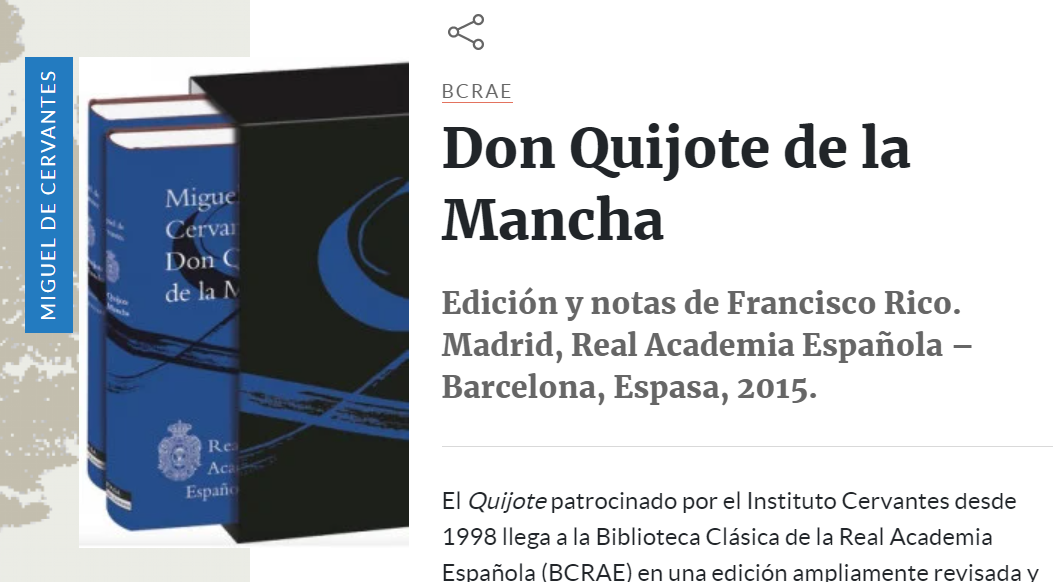

In [42]:
class TestWords(
    words: List[String] => List[String]
) extends FlatSpec with Matchers{
            
    val paragraph1 = List(
        "En un lugar",
        "de la Mancha", 
        "de cuyo nombre no",
        "quiero acordarme")
    
    "words" should "work" in {
        words(paragraph1) shouldBe 
            List(
                "En", "un", "lugar",
                "de", "la", "Mancha", 
                "de", "cuyo", "nombre", "no",
                "quiero", "acordarme")
    }
}

defined class TestWords

We may try to map the paragraph with a function that `split`s  each sentence into the words they are made of:

In [48]:
val paragraph: List[String] = 
    List("en un lugar", "de la Mancha")

"en un lugar".split(" ").toList

paragraph.map((phrase: String) => phrase.split(" ").toList)

paragraph: List[String] = List("en un lugar", "de la Mancha")
res47_1: List[String] = List("en", "un", "lugar")
res47_2: List[List[String]] = List(
  List("en", "un", "lugar"),
  List("de", "la", "Mancha")
)

In [47]:
List("en un lugar", "de la Mancha")
    .filter(_ == "en un lugar" : Boolean )

res46: List[String] = List("en un lugar")

In [55]:
def flatten[A](l: List[List[String]]): List[String] = 
    l.foldLeft(Nil : List[String])(
        (out: List[String], e: List[String]) => 
            out++e)

defined function flatten

In [58]:
def flatten[A](l: List[List[String]]): List[String] = 
    l.foldLeft(List[String]())(_++_)

defined function flatten

In [56]:
List("en", "un", "lugar") ++ List("de", "la", "Mancha")

res55: List[String] = List("en", "un", "lugar", "de", "la", "Mancha")

In [57]:
flatten(List(List("en", "un", "lugar"), 
             List("de", "la", "Mancha"))) ==
    List("en", "un", "lugar", 
         "de", "la", "Mancha")

res56: Boolean = true

but then we obtain a _list of lists_ of strings, not a list of plain strings. The solution is not far though: we have just to concatenate all the lists and we obtain what we need. The function `flatten` performs this concatenation:

In [ ]:
def flatten[A](listOflists: List[List[A]]): List[A] = 
    

The function `flatten` is actually provided by the Scala API. So, the implementation of the `words` function is as follows:

In [59]:
def words(paragraph: List[String]): List[String] = 
    flatten(
        map(paragraph)((p: String) => p.split(" ").toList)
        )

defined function words

In [63]:
def words(paragraph: List[String]): List[String] = 
    paragraph.flatMap(_.split(" ").toList)

defined function words

In [64]:
def words(paragraph: List[String]): List[String] = 
    paragraph.map(_.split(" ").toList)
        .flatten

defined function words

In [65]:
run(new TestWords(words))

cmd41$Helper$TestWords:
words
- should work


This combination of the HOF `map` and the function `flatten` is so common, that it has been given a proper name: `flatMap`. 

In [66]:
def  filter[A   ](list: List[A])(f: A => Boolean): List[A] =
    ???
def     map[A, B](list: List[A])(f: A =>      B ): List[B] = 
    ???
def flatMap[A, B](list: List[A])(f: A => List[B]): List[B] = 
    list.map(f).flatten

defined function filter
defined function map
defined function flatMap

![filter](../images/flatMap.svg)

Using `flatMap` the word function is implemented even more easily:

In [ ]:
def words(paragraph: List[String]): List[String] = 
    ???

### FlatMapping optional values

In [ ]:
def flatMap[A, B](maybeA: Option[A])(cont: A => Option[B]): Option[B] = 
    ???

In [ ]:
class TestFlatMapOption(
    flatMap: Option[Int] => (Int => Option[Boolean]) => Option[Boolean]
) extends FlatSpec with Matchers {
    
    def isPositiveEven(i: Int): Option[Boolean] = 
        if (i>=0) Some(i % 2 == 0)
        else None
    
    "flatMap" should "work" in {
        flatMap(None)(isPositiveEven) shouldBe ???
        flatMap(Some(5))(isPositiveEven) shouldBe ???
        flatMap(Some(-5))(isPositiveEven) shouldBe ???
        flatMap(Some(0))(isPositiveEven) shouldBe ???
        flatMap(Some(4))(isPositiveEven) shouldBe ???      
    }
}

In [ ]:
run(new TestFlatMapOption(flatMap))

## All together: a modularity problem

As before, we start from a list of sentences, but now we want to take care of the possible extra spaces between each word. Also, we want to obtain not the words themselves but their lengths. So, the specification of our problem is a function `lengths`:

In [73]:
class TestLengths(
    lengths: List[String] => List[Int]
) extends FlatSpec with Matchers{
            
    val paragraph1 = List(
        "En un  lugar",
        "de  la Mancha ", 
        "de cuyo nombre no",
        "quiero        acordarme")
    
    "lengths" should "work" in {
        lengths(paragraph1) shouldBe 
            List(2, 2, 5,
                2, 2, 6, // "de  la Mancha ", 
                2, 4, 6, 2, // "de cuyo nombre no",
                6, 9) // "quiero        acordarme")
    }
}

defined class TestLengths

In [74]:
"En un   lugar".split(" ")

res73: Array[String] = Array("En", "un", "", "", "lugar")

We may try to implement this function imperatively using mutable variables:

In [79]:
def lengthsM(paragraph: List[String]): List[Int] = {
    var out: List[Int] = List()
    for (phrase <- paragraph)
        for (word <- phrase.split(" "))
            if (word != "")
                out = word.length :: out
                // out = out.appended(word.length)
    out.reverse 
}


defined function lengthsM

and this works, of course: 

In [80]:
run(new TestLengths(lengthsM))

cmd72$Helper$TestLengths:
lengths
- should work


but can we do it better? Yes, we can! Using HOFs we can get a more concise, understandable and reliable version, with a great level of reuse!

In [83]:
List("En un   lugar", " de la   Mancha")
    .flatMap(_.split(" ").toList)
    .filter(word => word != "")
    .map(word => word.length)

res82: List[Int] = List(2, 2, 5, 2, 2, 6)

In [84]:
def lengthsHOF(paragraph: List[String]): List[Int] = 
    paragraph.flatMap(_.split(" ").toList)
        .filter(_ != "")
        .map(_.length)
    

defined function lengthsHOF

In [85]:
run(new TestLengths(lengthsHOF))

cmd72$Helper$TestLengths:
lengths
- should work


This solution contrasts with the mutable version in several respects:
- It's more **modular**, i.e. it's made of coarse-grained components: the HOFs `flatMap`, `filter` and `map`. The mutable version builds instead upon fine-grained components: `var`s, and `for` loops.
- The HOF components `flatMap`, etc., are actually very generic and domain-independent, and are typically part of standard libraries, so the level of **reuse** and **reliability** of the HOF-based solution is very high.
- The HOF-based solution is more **understandable**: it models the solution to the problem in terms of standard _transformations_ which are composed together using plain function composition. Moreover, these transformations are also at the right level of abstraction, i.e. it's natural to specify the solution to the problem in terms of flatMap, filter and map.

### For-comprehensions

The combination of `map`, `flatMap` and `filter` HOFs is so common, that Scala has a special syntax for them: for-comprehensions.

In [86]:
def lengthsFC(paragraph: List[String]): List[Int] = for {
    phrase <- paragraph 
    word <- phrase.split(" ").toList if word != ""
} yield word.length

defined function lengthsFC

In [87]:
run(new TestLengths(lengthsFC))

cmd72$Helper$TestLengths:
lengths
- should work
